# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 56 |  |
|(groep van 2)
| Zulfiqar Alwani| 6281265 |
| Wolf Peutz| 6436102|
| Planning Groep: 56    |vanaf 1100  |
|---|---|
| sanity check 3 af| 1130 |
| sensor bepaald en schets gemaakt met plot| 1215|
| Bepalen capaciteit| 1215-1230 |
| Opstelling en kalibreren| 1330-1430|
| Ontwerp en kalibratiegrafiek, itereren| 1430-1630 |
| Conclusie en koppelen leerdoelen, opruimen |1630-1730|
| Pauze 1, Pauze 2| 1230-1330, 1530-1540 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="tudelftLogo.png" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np  
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit    


def functieNaam(oppervlakte, afstand, diëlektrische_constante):
    epsilon_0 = 8.854187817e-12  
    
    # Formule: C = ε0 * εr * A / d
    output = epsilon_0 * diëlektrische_constante * oppervlakte / afstand
    
    return output
# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:


# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

oppervlakte_test= 0.01  # in vierkante meters, 10 bij 10 cm
afstand_test = 0.0022  # in meters, 1 mm
diëlektrische_constante_test = 2  # voor papier 3, voor lucht 1. Gewogen met hoe weinig papier er is, schatten wij het op 2
C = [functieNaam(oppervlakte_test, afstand_test, diëlektrische_constante_test)]


print(f"Berekende capaciteit plaatcondensator groep 56 is", C, "Farad")
print(f"Dit komt overeen met {C[0]*1e12:.1f} pF als capaciteit")

Vin= 8 # in Volt
Ceind= 80.5e-12 # in Farad
f= 100000 # in Hz
Rshunt= 1000 # in Ohm


Vout= Vin*2*np.pi*f*Ceind*Rshunt
print(f"De verwachte uitgangsspanning is {Vout:.2f} Volt")






Berekende capaciteit plaatcondensator groep 56 is [8.049261651818181e-11] Farad
Dit komt overeen met 80.5 pF als capaciteit
De verwachte uitgangsspanning is 0.40 Volt


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](P1.png)
![scope meting 2](P2.png)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 56| 80.5 pF|0.40 V| 0.40 V|79.9 pF|

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](P3.png)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die de druk meet. Zie schets, door gewicht te plaatsen op de platen wordt er druk gezet, hierdoor komen de platen vlakbij elkaar, en kan een verandering in capaciteit gemeten worden. 

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](P4.jpeg)

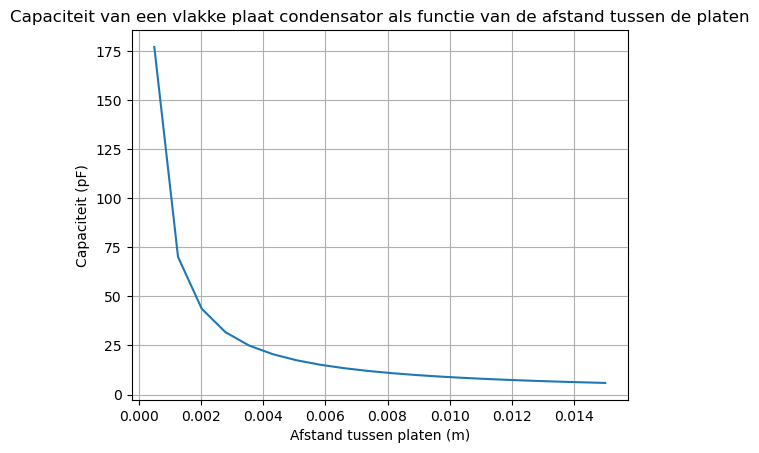

5.902791878 pF
177.08375634 pF
25.27800529184836 pF


In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

d= np.linspace(0.015, 0.0005, 20)
oppervlakte_test= 0.01  # in vierkante meters, 10 bij 10 cm
diëlektrische_constante_test = 1 #voor lucht
plt.plot(d, functieNaam(oppervlakte_test, d, diëlektrische_constante_test)*1e12)
plt.xlabel("Afstand tussen platen (m)")
plt.ylabel("Capaciteit (pF)")
plt.title("Capaciteit van een vlakke plaat condensator als functie van de afstand tussen de platen")
plt.grid()
plt.show()
print(np.min(functieNaam(oppervlakte_test, d, diëlektrische_constante_test)*1e12), "pF")
print(np.max(functieNaam(oppervlakte_test, d, diëlektrische_constante_test)*1e12), "pF")
print(np.mean(functieNaam(oppervlakte_test, d, diëlektrische_constante_test)*1e12), "pF")



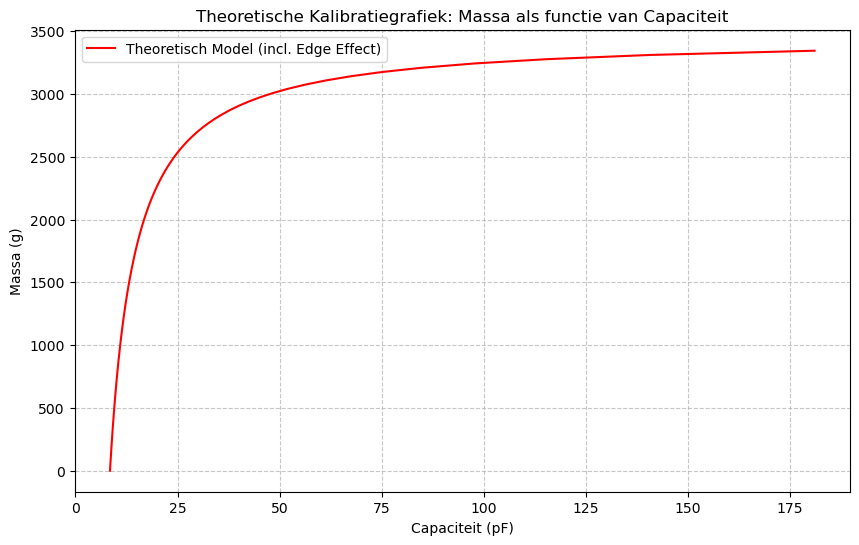

Theoretisch bereik: 8.45 pF tot 180.98 pF


In [4]:
import numpy as np
import matplotlib.pyplot as plt

epsilon_0 = 8.854187817e-12
epsilon_r = 1.0  
S = 0.01         
w = 0.1          
z0 = 0.015       # 15 mm startafstand
k = 4.335e-6     # Geschatte samendrukking in m/g

m = np.linspace(0, 3345, 100)
d = z0 - k * m   # De afstand d als functie van massa m

b = d / w
C0 = (epsilon_0 * epsilon_r * S) / d
C_theory = C0 * (1 + 2.343 * (b**0.891))

# Plotten
plt.figure(figsize=(10, 6))
plt.plot(C_theory * 1e12, m, 'r-', label='Theoretisch Model (incl. Edge Effect)')
plt.xlabel("Capaciteit (pF)")
plt.ylabel("Massa (g)")
plt.title("Theoretische Kalibratiegrafiek: Massa als functie van Capaciteit")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(f"Theoretisch bereik: {min(C_theory*1e12):.2f} pF tot {max(C_theory*1e12):.2f} pF")

## Opdracht 5: Invullen tabel LTSpice.

In [5]:
#C_min:
V_out = 78e-3
V_in = 8.00 

def capaciteit(V_out, V_in, f, Rshunt):
    Ceind = V_out / (V_in * 2 * np.pi * f * Rshunt)
    return Ceind

#C_min:
V_in = 8.00
V_out = 78e-3
f = 100000 # in Hz
Rshunt = 1000 # in Ohm
C_min = capaciteit(V_out, V_in, f, Rshunt)
print(f"Minimale capaciteit is {C_min*1e12:.1f} pF")

#C_max:
V_in = 8.00
V_out = 3403e-3 
f = 100000 # in Hz
Rshunt = 1000 # in Ohm
C_max = capaciteit(V_out, V_in, f, Rshunt)
print(f"Maximale capaciteit is {C_max*1e12:.1f} pF")

#gemiddelde capaciteit:
C_gemiddeld = (C_min + C_max) / 2
print(f"Gemiddelde capaciteit is {C_gemiddeld*1e12:.1f} pF")

Minimale capaciteit is 15.5 pF
Maximale capaciteit is 677.0 pF
Gemiddelde capaciteit is 346.3 pF


![LTSpice](P5.png)

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 5.9| 30 |
| gemiddelde capaciteit| 25.3 | 127 |
| maximale capaciteit| 177.1 | 873 |

## Opdracht 6: Foto's werkende opstelling.

## Opdracht 7: Plot de kalibratiegrafiek.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](P5.jpeg)


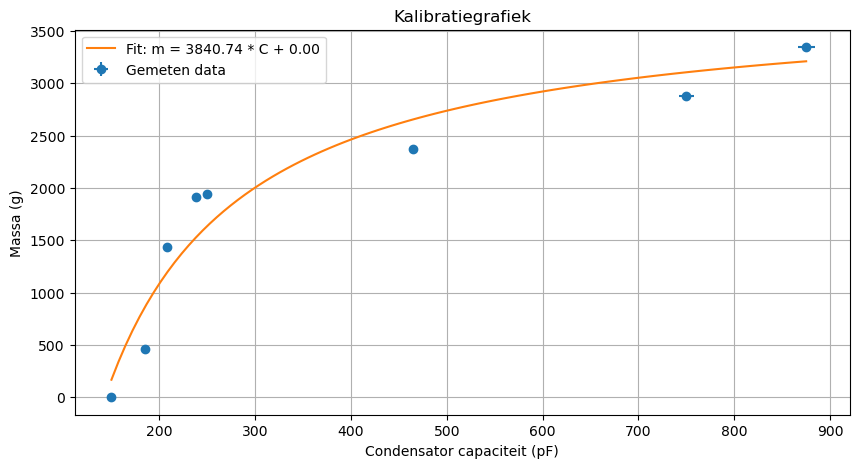

In [6]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit
m1= 973.3
m2=972.2
m3= 938.1
m4= 461.3
m = np.array([0, m4,m1+m4,m1+m3,m1+m2,m1+m3+m4,m1+m2+m3,m1+m2+m3+m4])
C = np.array([150,185,208, 238, 250, 465, 750, 875])*1e-12



def fitfunctie(C, a, b):
    return a-b/C
curve_fit(fitfunctie, C, m)
popt, pcov = curve_fit(fitfunctie, C, m)
a_fit, b_fit = popt
x_fit = np.linspace(np.min(C), np.max(C), 100)
y_fit = fitfunctie(x_fit, a_fit, b_fit)

plt.figure(figsize=(10, 5))
plt.errorbar(C*1e12, m, yerr=0.5, xerr=0.01*C*1e12, fmt='o', label='Gemeten data')
plt.plot(x_fit*1e12, y_fit, '-', label=f'Fit: m = {a_fit:.2f} * C + {b_fit:.2f}')
plt.xlabel("Condensator capaciteit (pF)")
plt.ylabel("Massa (g)")
plt.title("Kalibratiegrafiek")
plt.grid()
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* Verbetering 1: Massa perfect te centreren zodat indrukking accurater is, hier beter op letten tijdens gewicht plaatsen
* verbetering 2: 2 platen moeten preciezer ''op elkaar liggen'' zodat ze elkaar precies afdekken, dit is nu niet zo. Gebruik van stokken voor stabilisatie condensatorplaten

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](P6.jpeg)

In [7]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

#geen tijd voor extra iteratie meer, we zijn met zn 2en, maar resultaten zouden een kleinere spreiding moeten hebben als we meer iteraties hadden gedaan.
#Hierdoor curve fit netter
#Want indrukking is evenrediger, en condensatorplaten maken minder contact

## Opdracht 10: Vul hieronder de conclusie in.

Er valt te concluderen dat de sensor die wij hebben geschikt is om het fenomeen dat wij willen meten, de kracht die uitgeoefend wordt op de sponzen waardoor de condensatorplaten dichterbij elkaar komen, is gelukt. Er is te zien dat een grotere massa correspondeert met een grotere capaciteit, omdat de afstand d afneemt. De iteratie was geen tijd voor, maar zie onze verwachtingen. Er zit inderdaad een verschil tussen de voorspelling en de uiteindelijk gemeten kalibratiegrafiek, dit ook omdat wij de massas op elkaar moesten plaatsen, waardoor de indrukking door de tijd heen soms extra toenam. Echter lijkt de fit een y=sqrt(x) functie te volgen. De vlakke plaat formule voorspelt in enige zin erg goed dat een kleinere afstand tussen de platen correspondeert met een veel grotere capaciteit, waneeer de afstand d naar 0 mm gaat.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

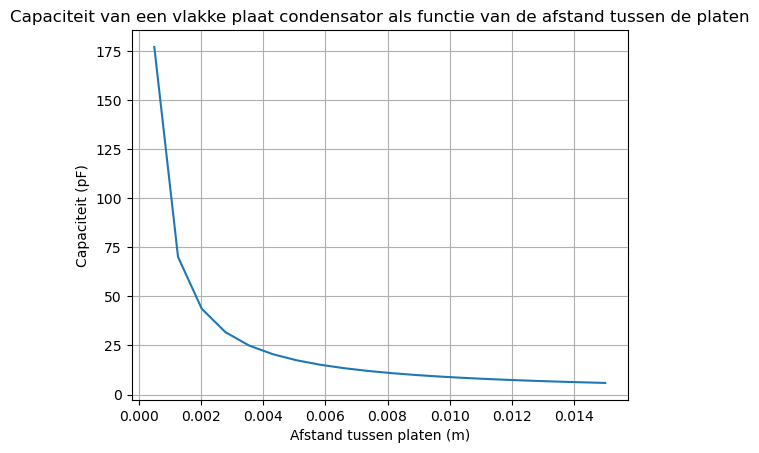

5.902791878 pF
177.08375634 pF
25.27800529184836 pF


In [8]:


# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

d= np.linspace(0.015, 0.0005, 20)
oppervlakte_test= 0.01  # in vierkante meters, 10 bij 10 cm
diëlektrische_constante_test = 1 #voor lucht
plt.plot(d, functieNaam(oppervlakte_test, d, diëlektrische_constante_test)*1e12)
plt.xlabel("Afstand tussen platen (m)")
plt.ylabel("Capaciteit (pF)")
plt.title("Capaciteit van een vlakke plaat condensator als functie van de afstand tussen de platen")
plt.grid()
plt.show()
print(np.min(functieNaam(oppervlakte_test, d, diëlektrische_constante_test)*1e12), "pF")
print(np.max(functieNaam(oppervlakte_test, d, diëlektrische_constante_test)*1e12), "pF")
print(np.mean(functieNaam(oppervlakte_test, d, diëlektrische_constante_test)*1e12), "pF")



#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](P5.jpeg)


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](P1.png)
![scope meting 2](P2.png)

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](P6.jpeg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 5.9| 30 |
| gemiddelde capaciteit| 25.3 | 127 |
| maximale capaciteit| 177.1 | 873 |

In [9]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np  
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit    


def functieNaam(oppervlakte, afstand, diëlektrische_constante):
    epsilon_0 = 8.854187817e-12  
    
    # Formule: C = ε0 * εr * A / d
    output = epsilon_0 * diëlektrische_constante * oppervlakte / afstand
    
    return output
# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

oppervlakte_test= 0.01  # in vierkante meters, 10 bij 10 cm
afstand_test = 0.0022  # in meters, 1 mm
diëlektrische_constante_test = 2  # voor papier 3, voor lucht 1. Gewogen met hoe weinig papier er is, schatten wij het op 2
C = [functieNaam(oppervlakte_test, afstand_test, diëlektrische_constante_test)]


print(f"Berekende capaciteit plaatcondensator groep 56 is", C, "Farad")
print(f"Dit komt overeen met {C[0]*1e12:.1f} pF als capaciteit")

Vin= 8 # in Volt
Ceind= 80.5e-12 # in Farad
f= 100000 # in Hz
Rshunt= 1000 # in Ohm


Vout= Vin*2*np.pi*f*Ceind*Rshunt
print(f"De verwachte uitgangsspanning is {Vout:.2f} Volt")





Berekende capaciteit plaatcondensator groep 56 is [8.049261651818181e-11] Farad
Dit komt overeen met 80.5 pF als capaciteit
De verwachte uitgangsspanning is 0.40 Volt


### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 56| 80.5 pF|0.40 V| 0.40 V|79.9 pF|

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

Er valt te concluderen dat de sensor die wij hebben geschikt is om het fenomeen dat wij willen meten, de kracht die uitgeoefend wordt op de sponzen waardoor de condensatorplaten dichterbij elkaar komen, is gelukt. Er is te zien dat een grotere massa correspondeert met een grotere capaciteit, omdat de afstand d afneemt. De iteratie was geen tijd voor, maar zie onze verwachtingen. Er zit inderdaad een verschil tussen de voorspelling en de uiteindelijk gemeten kalibratiegrafiek, dit ook omdat wij de massas op elkaar moesten plaatsen, waardoor de indrukking door de tijd heen soms extra toenam. Echter lijkt de fit een y=sqrt(x) functie te volgen. De vlakke plaat formule voorspelt in enige zin erg goed dat een kleinere afstand tussen de platen correspondeert met een veel grotere capaciteit, waneeer de afstand d naar 0 mm gaat.

/var/folders/pb/ck_h157s50jdw0k3wg0pz4qw0000gn/T/ipykernel_42418/1730466761.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


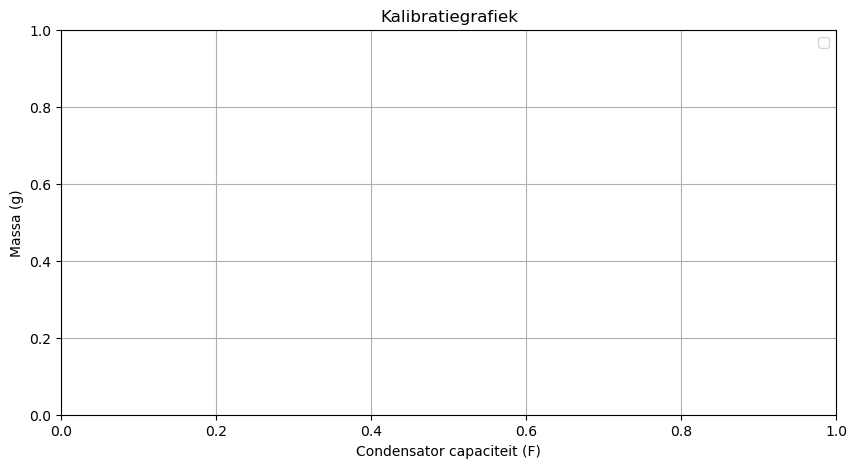

In [10]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit
m1= 973.3
m2=972.2
m3= 938.1
m4= 461.3
m = np.array([0, m4,m1+m4,m1+m3,m1+m2,m1+m3+m4,m1+m2+m3,m1+m2+m3+m4])
C = np.array([150,185,208, 238, 250, 465, 750, 875])*1e-12



def fitfunctie(C, a, b):
    return a-b/C
curve_fit(fitfunctie, C, m)
popt, pcov = curve_fit(fitfunctie, C, m)
a_fit, b_fit = popt
x_fit = np.linspace(np.min(C), np.max(C), 100)
y_fit = fitfunctie(x_fit, a_fit, b_fit)

plt.figure(figsize=(10, 5))

plt.xlabel("Condensator capaciteit (F)")
plt.ylabel("Massa (g)")
plt.title("Kalibratiegrafiek")
plt.grid()
plt.legend()
plt.show()

